# Client demo

Demonstrate the use of the Client (Assetto Corsa Sim interface) without the OpenAI Gym interface layer.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd
import glob as glob
import time
import pickle
from omegaconf import OmegaConf

# add custom paths
sys.path.extend([os.path.abspath('./assetto_corsa_gym')])
import AssettoCorsaEnv.assettoCorsa as assettoCorsa

# Configure the logging system
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,  # Set the logging level (DEBUG, INFO, WARNING, ERROR, CRITICAL)
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',  # Format of the log messages
    datefmt='%Y-%m-%d %H:%M:%S',  # Format of the timestamp
)


# load config file

In [2]:
config = OmegaConf.load("config.yml")
client = assettoCorsa.make_client_only(config.AssettoCorsa)

2026-04-07 15:48:09 - AssettoCorsaEnv.ac_client - WARNING - Controls will be executed locally and not by the server


# Show static info

In [3]:
static_info = client.simulation_management.get_static_info()
ac_mod_config = client.simulation_management.get_config()

logger.info("Static info:")
for i in static_info:
    logger.info(f"{i}: {static_info[i]}")
logger.info("AC Mod config:")
for i in ac_mod_config:
    logger.info(f"{i}: {ac_mod_config[i]}")


2026-04-07 15:48:09 - __main__ - INFO - Static info:
2026-04-07 15:48:09 - __main__ - INFO - TrackLength: 4591.88720703125
2026-04-07 15:48:09 - __main__ - INFO - CarName: ks_corvette_c7r
2026-04-07 15:48:09 - __main__ - INFO - TyreContactPoint_FR: [173.66021728515625, 2.0999605655670166, -538.52099609375]
2026-04-07 15:48:09 - __main__ - INFO - TrackName: ks_barcelona
2026-04-07 15:48:09 - __main__ - INFO - CAR_WHEEL_R: [0.3449999988079071, 0.3449999988079071, 0.35499998927116394, 0.35499998927116394]
2026-04-07 15:48:09 - __main__ - INFO - TyreContactPoint_RR: [171.56040954589844, 2.1464576721191406, -536.8129272460938]
2026-04-07 15:48:09 - __main__ - INFO - CAR_WHEELBASE: 2.7081598386377395
2026-04-07 15:48:09 - __main__ - INFO - TrackConfiguration: layout_gp
2026-04-07 15:48:09 - __main__ - INFO - WindDirection: 359
2026-04-07 15:48:09 - __main__ - INFO - WindSpeed: 0
2026-04-07 15:48:09 - __main__ - INFO - autoShifterOn: 1
2026-04-07 15:48:09 - __main__ - INFO - TyreContactPoint_

# Test gear shift

In [4]:
# test gear shifting
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=False)
client.controls.apply_local_controls()

time.sleep(1.0)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_down=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_down=False)
client.controls.apply_local_controls()

# Apply actions and recover the car

In [5]:
states = []

client.reset()

# shift up
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=False)
client.controls.apply_local_controls()

for i in range(100):
    if i % 2 == 0:
        steer = .1
    else:
        steer = -.1
    client.controls.set_controls(steer=steer, acc=0.5, brake=-1.)
    client.respond_to_server()
    state = client.step_sim()
    states.append(state.copy())
    time.sleep(0.01)

client.controls.set_defaults()
client.respond_to_server()
client.simulation_management.send_reset()
client.close()

2026-04-07 15:48:10 - AssettoCorsaEnv.ac_client - INFO - sending reset to simulation management server
2026-04-07 15:48:11 - AssettoCorsaEnv.ac_client - INFO - AC Client. Listening at host: localhost port: 2345
2026-04-07 15:48:11 - AssettoCorsaEnv.ac_client - INFO - Client connected on 2345
2026-04-07 15:48:16 - AssettoCorsaEnv.ac_client - INFO - sending reset to simulation management server


# Plot states

In [6]:
df = pd.DataFrame(states)
df.columns

Index(['done', 'BestLap', 'dynamic_pressure', 'accStatus', 'Dy_fr',
       'CamberRad', 'brakeStatus', 'LastFF', 'fr_wheel_load',
       'fr_tire_pressure', 'tyres_load', 'fr_damper_linear_potentiometer',
       'rl_tire_temperature_core', 'LapCount', 'RPM',
       'fl_tire_temperature_core', 'yaw', 'fl_tire_pressure',
       'rr_tire_temperature_core', 'fl_wheel_load', 'angular_velocity_y',
       'angular_velocity_x', 'rl_wheel_load', 'angular_velocity_z',
       'completedLaps', 'world_position_y', 'world_position_x',
       'tyreContactHeading_FR_y', 'total_errors_out_of_sync',
       'rr_tire_pressure', 'packetId', 'rr_damper_linear_potentiometer',
       'Dy_rl', 'currentTime', 'rr_wheel_load', 'timestamp_ac', 'Dy_rr',
       'tyreContactHeading_RL_y', 'tyreContactHeading_RL_x',
       'tyreContactHeading_RL_z', 'fl_damper_linear_potentiometer',
       'tyreContactHeading_FL_y', 'tyreContactHeading_FR_z', 'steps', 'accelX',
       'accelY', 'tyreContactHeading_FR_x', 'LapInvalida

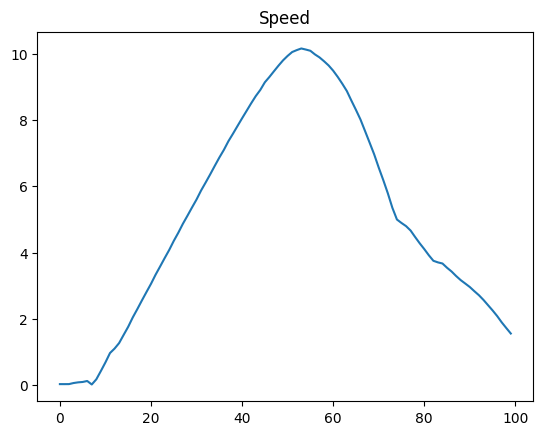

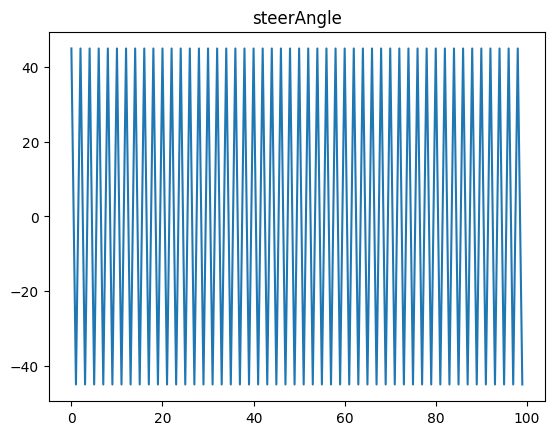

In [7]:
plt.title("Speed")
plt.plot(df.speed)
plt.show()

plt.title("steerAngle")
plt.plot(df.steerAngle)
plt.show()